# CS166 Final Project Code Notebook
Agent-based Monte Carlo simulation of the male loneliness spiral and algorithmic exposure.

This notebook:
- Defines the model and assumptions.
- Implements the simulation engine (OOP).
- Runs Monte Carlo experiments across interventions.
- Produces plots, histograms, and confidence intervals.


In [77]:
# Setup and imports
import os
# These environment variables limit BLAS and OpenMP threads for reproducibility and to
# avoid oversubscription slowdowns in notebooks.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import math
import random
import json
import hashlib

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


# Notebook helpers
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, filename):
    """Save a Matplotlib figure into the figures folder.

    This helper keeps figure saving consistent across the notebook and makes it easy to
    reuse plots in the report notebook.
    """
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def normalize_for_json(obj):
    """Convert common Python and NumPy objects into JSON-serializable types.

    This is used when hashing cache configurations and when writing cached result files.
    """
    if isinstance(obj, dict):
        return {str(k): normalize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [normalize_for_json(x) for x in obj]
    if hasattr(obj, "item") and callable(obj.item):
        try:
            return obj.item()
        except Exception:
            pass
    return obj

def config_hash(config):
    """Compute a short, deterministic hash for a cache configuration dictionary."""
    blob = json.dumps(normalize_for_json(config), sort_keys=True).encode("utf-8")
    return hashlib.sha1(blob).hexdigest()[:12]

def load_or_compute_json(cache_prefix, config, compute_fn):
    """Load a JSON cache keyed by a config hash, or compute and save it.

    The cache key changes whenever the config changes. If you change behavior but keep
    the same config keys, increment config['version'] to force recomputation.
    """
    os.makedirs(".cache", exist_ok=True)
    key = config_hash(config)
    path = os.path.join(".cache", f"{cache_prefix}_{key}.json")
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f), path
    value = compute_fn()
    with open(path, "w", encoding="utf-8") as f:
        json.dump(value, f)
    return value, path


## Model summary
Each agent i has isolation I_i, exposure R_i, ideological drift D_i, and social engagement S_i.
Friendships are weighted edges w_ij. The model updates are:

$R_i(t+1) = (1 - \alpha) R_i(t) + \alpha E_i(t)$, where $E_i(t) \sim \text{Bernoulli}(p_{alg}(I_i))$.

$p_{alg}(I) = p_0 + (p_{max} - p_0) I$.

$D_i(t+1) = D_i(t) + \beta R_i(t) (1 - S_i(t)) - \beta_{friend} \frac{1}{k_i} \sum_{j} w_{ij}(D_i - D_j)$.

$I_i(t+1) = I_i(t) + \gamma \frac{1}{k_i} \sum_{j} |D_i - D_j| - \delta S_i(t)$.

$w_{ij}(t+1) = w_{ij}(t) [1 - \mu_1 |D_i - D_j| - \mu_2 (I_i + I_j)/2]$.

Ties are cut with probability lambda when $|D_i - D_j| > \tau.$

Assumption: social engagement is derived from tie strength and isolation:
$S_i(t) = \text{avg}(w_i) \cdot (1 - I_i(t))$.
All state variables are clipped to [0, 1].


In [78]:
# Baseline parameters
BASE_PARAMS = {
    "n": 800,
    "T": 80,
    "network": "er",
    "k": 6,
    "rewire_p": 0.1,
    "er_mean_degree": 12,
    "scale_free_m": 3,
    "w_min": 0.3,
    "w_max": 0.9,
    "init_I_a": 2.0,
    "init_I_b": 5.0,
    "init_D_a": 2.0,
    "init_D_b": 5.0,
    "init_R_a": 1.0,
    "init_R_b": 8.0,
    "alpha": 0.30,
    "p0": 0.05,
    "p_max": 0.60,
    "beta": 0.35,
    "beta_friend": 0.60,
    "gamma": 0.25,
    "delta": 0.25,
    "mu1": 0.25,
    "mu2": 0.20,
    "tau": 0.60,
    "lambda": 0.10,
}


## Parameters and outputs

**Randomness (Monte Carlo):**
- Random network generation and initial conditions (I, R, D).
- Per-timestep algorithm exposure sampled as a Bernoulli event with probability $p_{alg}(I_i)$.
- Friendship dissolution when $|D_i-D_j|>\tau$ occurs with probability $\lambda$.

**Key parameters (how to read them):**
- `alpha`: smoothing rate for exposure `R` (higher = exposure responds faster).
- `p0`, `p_max`: baseline and maximum algorithm exposure probability; `(p_max - p0)` is the “algorithm slope”.
- `beta`: strength of red-pill exposure on drift.
- `beta_friend`: corrective social influence pulling drift toward friends.
- `gamma`: how much ideological mismatch increases isolation.
- `delta`: how much social engagement reduces isolation.
- `mu1`, `mu2`: rates at which ideology gaps and isolation erode friendship weights.
- `tau`, `lambda`: cutoff threshold and probability of severing ties.


**Network parameters:**
- ER (Erdős–Rényi): set `network="er"` and choose `er_mean_degree` (expected degree).
- SBM (high-school extension): set `network="sbm"` with `sbm_block_sizes`, `sbm_p_in`, `sbm_p_out`.

**Quantities of interest (reported per simulation run):**
- `mean_drift`: average final $D_i(T)$ across agents.
- `mean_isolation`: average final $I_i(T)$ across agents.
- `mean_exposure`: average final $R_i(T)$ across agents.
- `isolated_frac`: fraction of agents with degree 0 (no friends) at the end.
- `avg_weight`: average remaining friendship weight at the end.

In addition to run-level summaries, I also visualize the **distribution of final drift values** $\{D_i(T)\}$ across agents in a single run to show within-run heterogeneity.


In [79]:
class LonelinessModel:
    """Agent-based network simulation of a loneliness feedback loop.
    
    This class implements the update rules used in the project report. It evolves agent
    states on a weighted friendship network and allows ties to weaken and be cut over
    time.
    
    State per agent:
    - `I`: isolation in [0,1]
    - `R`: red pill exposure in [0,1]
    - `D`: ideological drift in [0,1]
    - `S`: social engagement in [0,1] (recomputed each timestep)
    
    The friendship network is an undirected weighted `networkx.Graph` with edge
    attribute `weight` in [0,1].
    
    All stochasticity is generated from the NumPy random generator seeded in `__init__`,
    including network generation, initial state draws, exposure events, and tie cutting.
    """
    def __init__(self, params, seed=0):
        """Initialize the friendship network and agent states.

        Args:
            params: Dict of model parameters.
            seed: Integer seed that controls network generation, initial states, and
                all randomness during the run.
        """
        self.params = params
        # A single RNG controls all randomness for reproducibility.
        self.rng = np.random.default_rng(seed)
        self.G = self._make_network()
        self.I, self.R, self.D = self._init_states()
        self.S = np.zeros_like(self.I)

    @staticmethod
    def _clip01(x):
        """Clip a scalar value to the interval [0, 1]."""
        return max(0.0, min(1.0, x))

    def _make_network(self):
        """Create the initial friendship graph and initialize edge weights.

        The graph generator is selected by params['network']. NetworkX expects a
        Python int or random.Random as the seed, so NumPy integers are cast to int.
        """
        n = self.params["n"]
        if self.params["network"] == "small_world":
            G = nx.watts_strogatz_graph(
                n,
                self.params["k"],
                self.params["rewire_p"],
                seed=int(self.rng.integers(0, 1_000_000)),
            )
        elif self.params["network"] == "scale_free":
            G = nx.barabasi_albert_graph(
                n,
                self.params["scale_free_m"],
                seed=int(self.rng.integers(0, 1_000_000)),
            )
        elif self.params["network"] == "er":
            # ER graph with expected mean degree.
            mean_deg = float(self.params.get("er_mean_degree", self.params.get("k", 6)))
            p = max(0.0, min(1.0, mean_deg / max(1, (n - 1))))
            G = nx.erdos_renyi_graph(n, p, seed=int(self.rng.integers(0, 1_000_000)))
        elif self.params["network"] == "sbm":
            # Stochastic block model for community structure (e.g., grades/classes).
            sizes = list(self.params["sbm_block_sizes"])
            if sum(sizes) != n:
                raise ValueError("sbm_block_sizes must sum to n")
            p_in = float(self.params["sbm_p_in"])
            p_out = float(self.params["sbm_p_out"])
            B = len(sizes)
            probs = [[p_out] * B for _ in range(B)]
            for b in range(B):
                probs[b][b] = p_in
            G = nx.stochastic_block_model(sizes, probs, seed=int(self.rng.integers(0, 1_000_000)))
        else:
            raise ValueError("Unknown network model")
        for u, v in G.edges():
            G[u][v]["weight"] = self.rng.uniform(self.params["w_min"], self.params["w_max"])
        return G

    def _init_states(self):
        """Sample initial agent states from the Beta distributions in params."""
        n = self.params["n"]
        I = self.rng.beta(self.params["init_I_a"], self.params["init_I_b"], size=n)
        D = self.rng.beta(self.params["init_D_a"], self.params["init_D_b"], size=n)
        R = self.rng.beta(self.params["init_R_a"], self.params["init_R_b"], size=n)
        return I, R, D

    def _compute_neighbor_stats(self):
        """Compute neighbor aggregates used in the state update rules.

        Returns weighted sums and degrees so updates can be vectorized over nodes.
        """
        n = len(self.D)
        sum_diff = np.zeros(n)
        sum_abs = np.zeros(n)
        sum_w = np.zeros(n)
        deg = np.zeros(n, dtype=int)

        for u, v, data in self.G.edges(data=True):
            # diff is signed so sum_diff captures a Laplacian-like pull to neighbors.
            w = data["weight"]
            diff = self.D[u] - self.D[v]
            sum_diff[u] += w * diff
            sum_diff[v] -= w * diff
            absdiff = abs(diff)
            sum_abs[u] += absdiff
            sum_abs[v] += absdiff
            sum_w[u] += w
            sum_w[v] += w
            deg[u] += 1
            deg[v] += 1

        return sum_diff, sum_abs, sum_w, deg

    def _compute_engagement(self, sum_w, deg):
        """Compute social engagement S_i from average tie strength and isolation."""
        S = np.zeros_like(self.I)
        mask = deg > 0
        S[mask] = (sum_w[mask] / deg[mask]) * (1.0 - self.I[mask])
        return np.clip(S, 0.0, 1.0)

    def step(self):
        """Advance the simulation by one timestep.

        The implementation updates a derived engagement signal, then updates agent
        states, and finally updates the social network.
        """
        sum_diff, sum_abs, sum_w, deg = self._compute_neighbor_stats()
        # Social engagement depends on current ties and current isolation.
        self.S = self._compute_engagement(sum_w, deg)

        # Algorithmic exposure is modeled as a Bernoulli event with probability p_alg(I).
        p_alg = self.params["p0"] + (self.params["p_max"] - self.params["p0"]) * self.I
        p_alg = np.clip(p_alg, 0.0, 1.0)
        exposure = (self.rng.random(len(self.I)) < p_alg).astype(float)

        # Exposure updates are smoothed with an exponential moving average.
        R_new = (1.0 - self.params["alpha"]) * self.R + self.params["alpha"] * exposure

        # Drift uses R(t) rather than R(t+1) so exposure affects drift starting next step.
        D_new = self.D + self.params["beta"] * self.R * (1.0 - self.S)
        mask = deg > 0
        D_new[mask] -= self.params["beta_friend"] * (sum_diff[mask] / deg[mask])
        D_new = np.clip(D_new, 0.0, 1.0)

        I_new = self.I.copy()
        I_new[mask] += self.params["gamma"] * (sum_abs[mask] / deg[mask]) - self.params["delta"] * self.S[mask]
        I_new[~mask] = self.I[~mask]
        I_new = np.clip(I_new, 0.0, 1.0)

        # Update friendship weights and optionally cut ties that exceed the drift threshold.
        for u, v, data in list(self.G.edges(data=True)):
            diff = abs(self.D[u] - self.D[v])
            w = data["weight"]
            w_new = w * (1.0 - self.params["mu1"] * diff - self.params["mu2"] * (self.I[u] + self.I[v]) / 2.0)
            w_new = self._clip01(w_new)
            if diff > self.params["tau"] and self.rng.random() < self.params["lambda"]:
                self.G.remove_edge(u, v)
            else:
                data["weight"] = w_new

        self.I, self.R, self.D = I_new, R_new, D_new

    def compute_metrics(self):
        """Compute run-level summary metrics from the current state.

        These metrics match what is reported in the Monte Carlo experiment section.
        """
        n = len(self.I)
        edges = list(self.G.edges(data=True))
        avg_weight = float(np.mean([d["weight"] for _, _, d in edges])) if edges else 0.0
        isolated = sum(1 for i in self.G.nodes() if self.G.degree(i) == 0) / n
        return {
            "mean_isolation": float(np.mean(self.I)),
            "mean_drift": float(np.mean(self.D)),
            "mean_exposure": float(np.mean(self.R)),
            "isolated_frac": float(isolated),
            "avg_weight": float(avg_weight),
        }

    def run(self, T=None, track=True):
        """Run the model forward for T steps.

        Args:
            T: Number of timesteps to simulate. If None, uses params['T'].
            track: If True, record time-series aggregates at each step.

        Returns:
            metrics: Dict of final summary metrics.
            series: Dict of time-series lists when track is True.
            G: The final friendship graph.
            state: Dict of final per-agent arrays.
        """
        steps = T if T is not None else self.params["T"]
        series = {
            "mean_I": [],
            "mean_D": [],
            "mean_R": [],
            "mean_S": [],
            "num_edges": [],
            "mean_R_1minusS": [],
            "frac_D_at_bounds": [],
        }

        for _ in range(steps):
            self.step()
            if track:
                series["mean_I"].append(float(np.mean(self.I)))
                series["mean_D"].append(float(np.mean(self.D)))
                series["mean_R"].append(float(np.mean(self.R)))
                series["mean_S"].append(float(np.mean(self.S)))
                series["mean_R_1minusS"].append(float(np.mean(self.R * (1.0 - self.S))))
                series["frac_D_at_bounds"].append(float(np.mean((self.D <= 1e-12) | (self.D >= 1.0 - 1e-12))))
                series["num_edges"].append(self.G.number_of_edges())

        metrics = self.compute_metrics()
        state = {
            "I": self.I.copy(),
            "R": self.R.copy(),
            "D": self.D.copy(),
            "S": self.S.copy(),
        }
        return metrics, series, self.G, state

    @staticmethod
    def plot_network(G, values, title, save_path=None, show=True, pos=None):
        """Plot a network snapshot with node colors given by values.

        Args:
            G: A NetworkX graph.
            values: Sequence of per-node values in [0,1] used to color nodes.
            title: Plot title.
            save_path: Optional path to save a PNG.
            show: If True, display the plot.
            pos: Optional fixed layout dict so multiple snapshots are comparable.

        Returns:
            The Matplotlib Figure, or None if the graph is empty.
        """
        if G.number_of_nodes() == 0:
            return None
        if pos is None:
            pos = nx.spring_layout(G, seed=1, iterations=50)
        node_colors = [values[i] for i in G.nodes()]
        fig, ax = plt.subplots(figsize=(6, 5))
        nodes = nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_color=node_colors,
            cmap='viridis',
            vmin=0,
            vmax=1,
            node_size=50,
        )
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5)
        cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('ideological drift D_i')
        cbar.set_ticks([0.0, 0.5, 1.0])
        ax.set_title(title)
        ax.axis('off')
        if save_path:
            fig.savefig(save_path, dpi=200, bbox_inches='tight')
        if show:
            plt.show()
        return fig
class ExperimentRunner:
    """Run Monte Carlo experiments over multiple scenarios.
    
    Each scenario is a params dict; each run uses the same seed across scenarios for fair comparison.
    """
    def __init__(self, scenarios, num_runs, seed=0):
        """Create a runner for repeated simulations.

        Args:
            scenarios: Dict mapping scenario name to a params dict.
            num_runs: Number of Monte Carlo runs per scenario.
            seed: Base seed. Run r uses seed + r for all scenarios so comparisons are fair.
        """
        self.scenarios = scenarios
        self.num_runs = num_runs
        self.seed = seed

    def run(self):
        """Execute the experiment set and return a dict of metric lists.

        Each run index uses the same random seed across scenarios so that differences
        in outcomes are driven by the intervention rather than by unrelated randomness.
        """
        results = {name: [] for name in self.scenarios}
        for run_idx in range(self.num_runs):
            run_seed = self.seed + run_idx
            for name, params in self.scenarios.items():
                model = LonelinessModel(params, seed=run_seed)
                metrics, _, _, _ = model.run(track=False)
                results[name].append(metrics)
        return results


def mean_ci(values, z=1.96):
    """Compute a normal-approximation confidence interval for the mean.

    This uses a normal approximation with critical value z. In this project, z=1.96
    corresponds to a 95% confidence interval.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = float(np.mean(values))
    if n < 2:
        return mean, (mean, mean)
    se = float(np.std(values, ddof=1)) / math.sqrt(n)
    return mean, (mean - z * se, mean + z * se)


In [80]:
# Sanity checks 
def run_sanity_checks():
    """Run a lightweight set of checks to validate the implementation.

    These are not exhaustive unit tests. They are designed to catch common mistakes
    in the update rules, such as values leaving [0,1] or parameters not having the
    expected qualitative effect.
    """
    # Use a small, fast run so checks execute quickly in the notebook.
    params = dict(BASE_PARAMS)
    params.update({"n": 40, "T": 5})
    m = LonelinessModel(params, seed=123)

    # Invariant: states stay in [0,1] and weights stay in [0,1].
    m.step()
    assert np.all((0 <= m.I) & (m.I <= 1))
    assert np.all((0 <= m.R) & (m.R <= 1))
    assert np.all((0 <= m.D) & (m.D <= 1))
    assert np.all((0 <= m.S) & (m.S <= 1))
    for _, _, d in m.G.edges(data=True):
        assert 0 <= d["weight"] <= 1

    # Engagement should be tied to the network and isolation, so it should generally change over time.
    S0 = m.S.copy()
    m.step()
    S1 = m.S.copy()
    assert np.any(np.abs(S1 - S0) > 1e-12)

    # If friendship erosion and cutting are disabled, weights should not change.
    params2 = dict(params)
    params2.update({"mu1": 0.0, "mu2": 0.0, "lambda": 0.0})
    m2 = LonelinessModel(params2, seed=123)
    w_before = [d["weight"] for _, _, d in m2.G.edges(data=True)]
    m2.step()
    w_after = [d["weight"] for _, _, d in m2.G.edges(data=True)]
    assert np.allclose(w_before, w_after)

    # If the algorithm never exposes anyone, exposure should decay toward 0.
    params3 = dict(params)
    params3.update({"p0": 0.0, "p_max": 0.0})
    m3 = LonelinessModel(params3, seed=123)
    r0 = float(np.mean(m3.R))
    m3.step()
    r1 = float(np.mean(m3.R))
    assert r1 <= r0 + 1e-12

    # If drift forces are disabled, D should remain unchanged.
    params4 = dict(params)
    params4.update({"beta": 0.0, "beta_friend": 0.0})
    m4 = LonelinessModel(params4, seed=123)
    d0 = m4.D.copy()
    m4.step()
    assert np.allclose(d0, m4.D)

    print("Sanity checks passed.")

run_sanity_checks()


Sanity checks passed.


Saved figure: figures/er_single_run_timeseries.png


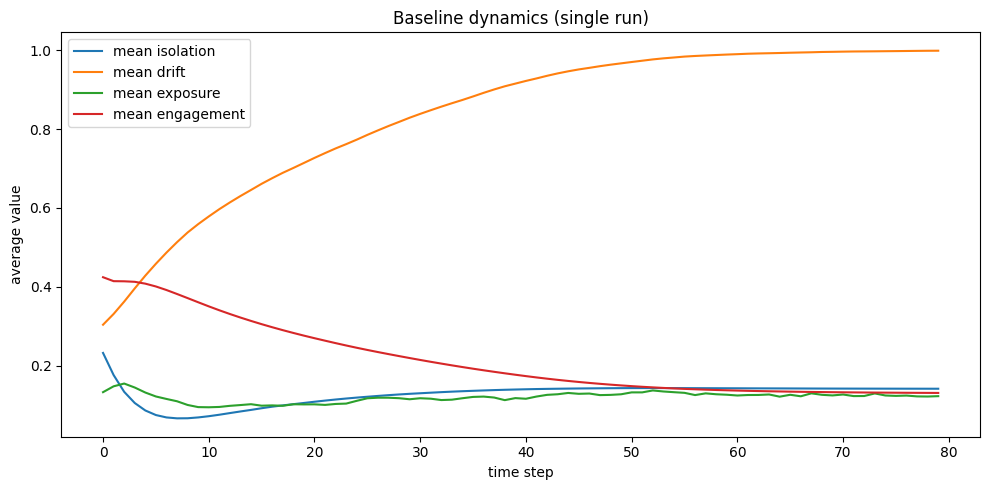

In [81]:
# Single-run demonstration
model = LonelinessModel(BASE_PARAMS, seed=RANDOM_SEED)
G_init = model.G.copy()
I0, R0, D0, S0 = model.I.copy(), model.R.copy(), model.D.copy(), model.S.copy()
metrics, series, G, state = model.run(track=True)
metrics

# Time-series plots
t = range(len(series["mean_I"]))
plt.figure(figsize=(10, 5))
plt.plot(t, series["mean_I"], label="mean isolation")
plt.plot(t, series["mean_D"], label="mean drift")
plt.plot(t, series["mean_R"], label="mean exposure")
plt.plot(t, series["mean_S"], label="mean engagement")
plt.legend()
plt.xlabel("time step")
plt.ylabel("average value")
plt.title("Baseline dynamics (single run)")
plt.tight_layout()
fig = plt.gcf()
save_fig(fig, 'er_single_run_timeseries.png')
plt.show()



Saved figure: figures/er_final_drift_distribution.png


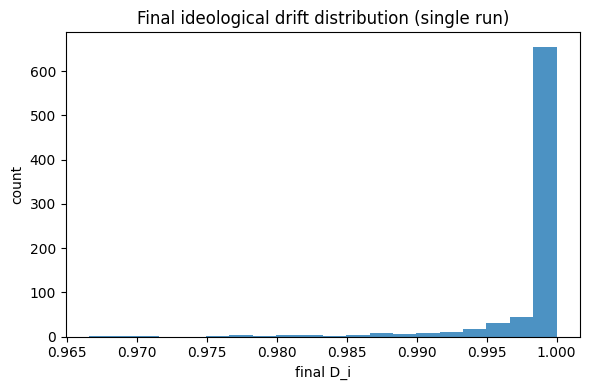

In [82]:
# Distribution of drift across agents (end of single run)
plt.figure(figsize=(6, 4))
plt.hist(state["D"], bins=20, alpha=0.8)
plt.xlabel("final D_i")
plt.ylabel("count")
plt.title("Final ideological drift distribution (single run)")
plt.tight_layout()
fig = plt.gcf()
save_fig(fig, 'er_final_drift_distribution.png')
plt.show()


## Animate the simulation state

This animation is a visual correctness check: you can watch drift and friendships evolve over time.
To keep it fast, it uses a smaller network than the main experiments.


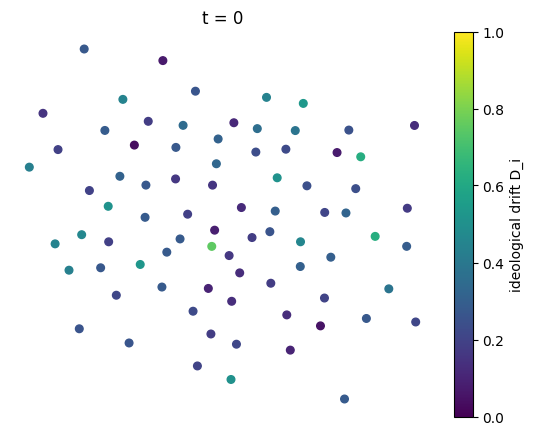

In [ ]:
# Animation
# This section visualizes the evolving network state to demonstrate that the
# implementation behaves as expected over time.
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection

ANIM_PARAMS = dict(BASE_PARAMS)
ANIM_PARAMS.update({"n": 80, "T": 60})

anim_model = LonelinessModel(ANIM_PARAMS, seed=RANDOM_SEED)
pos = nx.spring_layout(anim_model.G, seed=1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis("off")

# Initial artists
node_xy = np.array([pos[i] for i in anim_model.G.nodes()])
sc = ax.scatter(node_xy[:, 0], node_xy[:, 1], c=anim_model.D, cmap="viridis", vmin=0, vmax=1, s=30)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("ideological drift D_i")

lc = LineCollection([], colors=(0, 0, 0, 0.15), linewidths=0.5)
ax.add_collection(lc)

title = ax.set_title("t = 0")

def edge_segments_and_widths(G):
    """Convert graph edges into line segments and widths for LineCollection."""
    segs = []
    widths = []
    for u, v, d in G.edges(data=True):
        segs.append([pos[u], pos[v]])
        w = float(d.get("weight", 0.0))
        widths.append(0.2 + 2.0 * w)
    return segs, widths

def update(frame):
    """Advance one timestep and update the plotted artists."""
    # Step the model forward and update artists.
    anim_model.step()
    sc.set_array(anim_model.D)
    segs, widths = edge_segments_and_widths(anim_model.G)
    lc.set_segments(segs)
    lc.set_linewidths(widths)
    title.set_text(f"t = {frame+1} | mean D={np.mean(anim_model.D):.2f} | mean I={np.mean(anim_model.I):.2f} | edges={anim_model.G.number_of_edges()}")
    return sc, lc, title

ani = FuncAnimation(fig, update, frames=ANIM_PARAMS["T"], interval=200, blit=False)
plt.show()

# Save as a GIF.
# This can take a bit of time because it renders every frame.
ani.save("simulation.gif", writer="pillow", fps=5)


## Monte Carlo experiments
I compare multiple interventions by running the simulation many times and
analyzing the distribution of outcomes.


In [84]:
SCENARIOS = {
    'baseline': dict(BASE_PARAMS),
    'lower_algo': {**BASE_PARAMS, 'p_max': 0.35},
    'boost_support': {**BASE_PARAMS, 'delta': 0.40},
    'stronger_friends': {**BASE_PARAMS, 'beta_friend': 0.85},
}

NUM_RUNS = 200

# Cache configuration for the expensive Monte Carlo experiment.
# If you change the simulation code but keep the same config fields, bump version
# to force recomputation.
cache_config = {
    'version': 1,
    'scenarios': SCENARIOS,
    'num_runs': NUM_RUNS,
    'seed': RANDOM_SEED,
}

def _compute_results():
    """Compute Monte Carlo results for all scenarios.

    This is separated into a function so it can be passed into the cache helper.
    """
    return ExperimentRunner(SCENARIOS, NUM_RUNS, seed=RANDOM_SEED).run()

results, cache_path = load_or_compute_json('results', cache_config, _compute_results)
print('Monte Carlo results cache:', cache_path)


Monte Carlo results cache: .cache/results_aa8417e88e19.json


In [85]:
# Confidence intervals on key outcomes
metrics_to_report = ["mean_drift", "mean_isolation", "mean_exposure", "isolated_frac", "avg_weight"]


for metric in metrics_to_report:
    print(f"\nMetric: {metric}")
    for name, rows in results.items():
        values = [r[metric] for r in rows]
        mean, (lo, hi) = mean_ci(values)
        print(f"  {name:16s} mean={mean:.3f}  95% CI=({lo:.3f}, {hi:.3f})")



Metric: mean_drift
  baseline         mean=0.998  95% CI=(0.998, 0.998)
  lower_algo       mean=0.997  95% CI=(0.997, 0.997)
  boost_support    mean=0.997  95% CI=(0.997, 0.997)
  stronger_friends mean=1.000  95% CI=(1.000, 1.000)

Metric: mean_isolation
  baseline         mean=0.140  95% CI=(0.138, 0.141)
  lower_algo       mean=0.120  95% CI=(0.118, 0.121)
  boost_support    mean=0.042  95% CI=(0.041, 0.043)
  stronger_friends mean=0.099  95% CI=(0.097, 0.100)

Metric: mean_exposure
  baseline         mean=0.127  95% CI=(0.126, 0.128)
  lower_algo       mean=0.086  95% CI=(0.085, 0.087)
  boost_support    mean=0.073  95% CI=(0.072, 0.074)
  stronger_friends mean=0.105  95% CI=(0.104, 0.106)

Metric: isolated_frac
  baseline         mean=0.000  95% CI=(0.000, 0.000)
  lower_algo       mean=0.000  95% CI=(0.000, 0.000)
  boost_support    mean=0.000  95% CI=(0.000, 0.000)
  stronger_friends mean=0.000  95% CI=(0.000, 0.000)

Metric: avg_weight
  baseline         mean=0.134  95% CI=(0.1

Saved figure: figures/er_mc_ci_errorbars.png


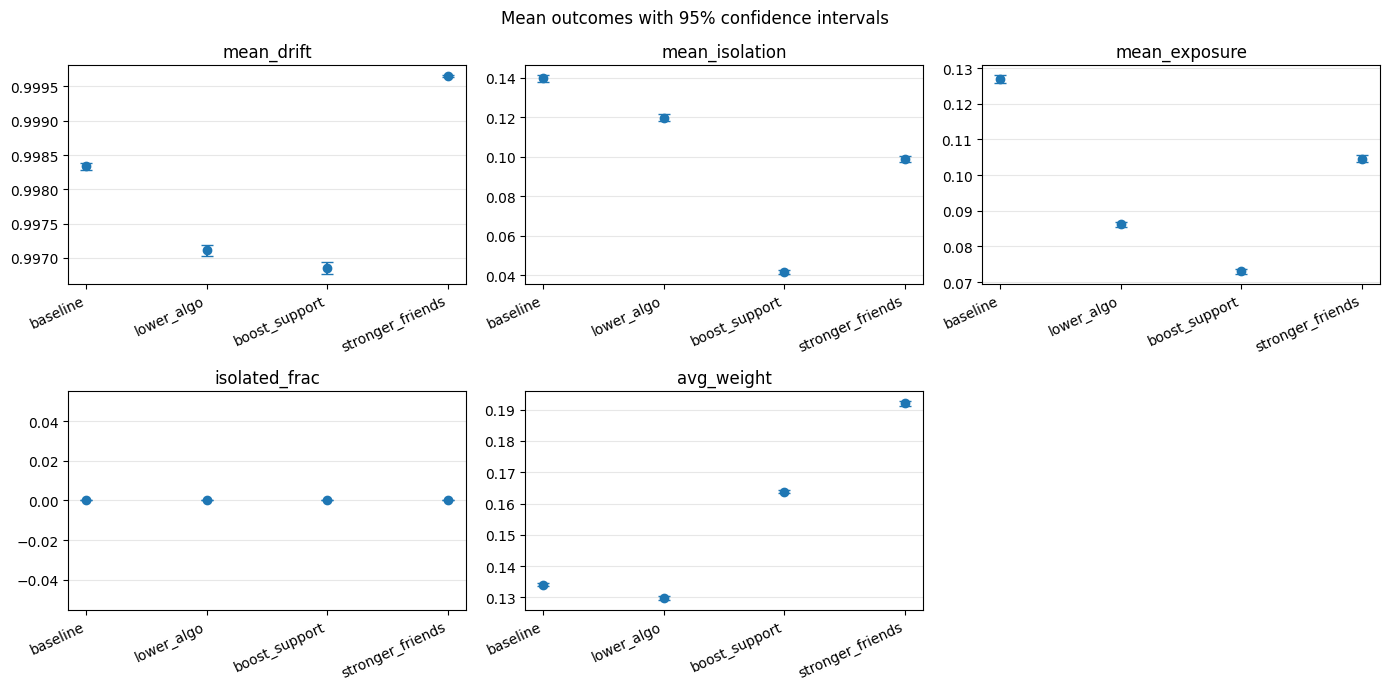

In [86]:
# Visualize 95% confidence intervals (error bars)
# This plot summarizes the Monte Carlo results as expected values with uncertainty.
def summarize_cis(results, metrics):
    """Compute mean and 95% confidence interval per metric and scenario.

    This uses the same mean_ci helper as the rest of the notebook.
    """
    summary = {m: {} for m in metrics}
    for m in metrics:
        for scenario, rows in results.items():
            vals = [r[m] for r in rows]
            mean, (lo, hi) = mean_ci(vals)
            summary[m][scenario] = {"mean": mean, "lo": lo, "hi": hi}
    return summary

ci_summary = summarize_cis(results, metrics_to_report)

scenarios = list(results.keys())
x = np.arange(len(scenarios))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax_idx, metric in enumerate(metrics_to_report):
    ax = axes[ax_idx]
    means = [ci_summary[metric][s]["mean"] for s in scenarios]
    los = [ci_summary[metric][s]["lo"] for s in scenarios]
    his = [ci_summary[metric][s]["hi"] for s in scenarios]
    yerr = [np.array(means) - np.array(los), np.array(his) - np.array(means)]
    ax.errorbar(x, means, yerr=yerr, fmt="o", capsize=4)
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.3)


for j in range(len(metrics_to_report), len(axes)):
    axes[j].axis("off")

fig.suptitle("Mean outcomes with 95% confidence intervals")
plt.tight_layout()
save_fig(fig, 'er_mc_ci_errorbars.png')
plt.show()


In [87]:
# Monte Carlo uncertainty: how many runs are enough?
def required_runs_for_halfwidth(values, target_halfwidth, z=1.96):
    """Estimate runs needed so the mean CI half-width is at most target_halfwidth.

    This uses the approximate scaling half_width ≈ z * s / sqrt(N).
    """
    values = np.asarray(values, dtype=float)
    s = float(np.std(values, ddof=1))
    if target_halfwidth <= 0 or s == 0:
        return 1
    return int(math.ceil((z * s / target_halfwidth) ** 2))

def ci_halfwidth(values, z=1.96):
    """Compute the normal-approximation CI half-width for the mean."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < 2:
        return 0.0
    se = float(np.std(values, ddof=1)) / math.sqrt(n)
    return z * se

metric = "mean_drift"
vals = [r[metric] for r in results["baseline"]]
hw = ci_halfwidth(vals)
print(f"Baseline {metric} CI half-width with M={len(vals)} runs: {hw:.4f}")
target = hw / 2
needed = required_runs_for_halfwidth(vals, target)
print(f"Estimated runs needed to halve half-width (~{target:.4f}): {needed}")


Baseline mean_drift CI half-width with M=200 runs: 0.0000
Estimated runs needed to halve half-width (~0.0000): 801


Saved figure: figures/er_mc_histograms_mean_drift_isolation.png


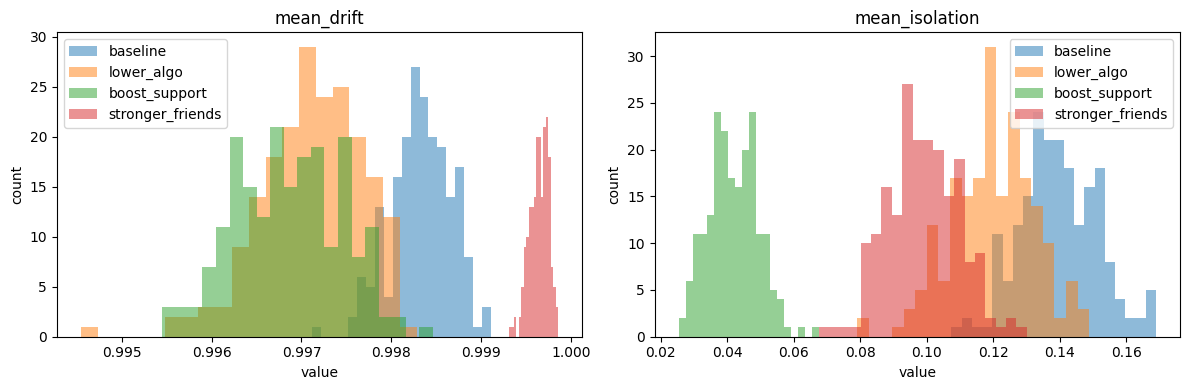

In [88]:
# Histograms of Monte Carlo outcomes
metrics_to_plot = ["mean_drift", "mean_isolation"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    for name, rows in results.items():
        values = [r[metric] for r in rows]
        ax.hist(values, bins=20, alpha=0.5, label=name)
    ax.set_title(metric)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
save_fig(fig, 'er_mc_histograms_mean_drift_isolation.png')
plt.show()


Initial edges: 4821  | clustering: 0.015189029037174817
Final edges: 4816  | clustering: 0.01518028084092662
Final snapshot metrics: {'mean_isolation': 0.14175211157136516, 'mean_drift': 0.9985781781795248, 'mean_exposure': 0.12290345188291571, 'isolated_frac': 0.0, 'avg_weight': 0.13075540054158152}


/var/folders/wk/4dx3s0td2p5fk3_hbsdcp03h0000gn/T/ipykernel_13879/3232603092.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.95])


Saved figure: figures/er_network_initial_vs_final2.png


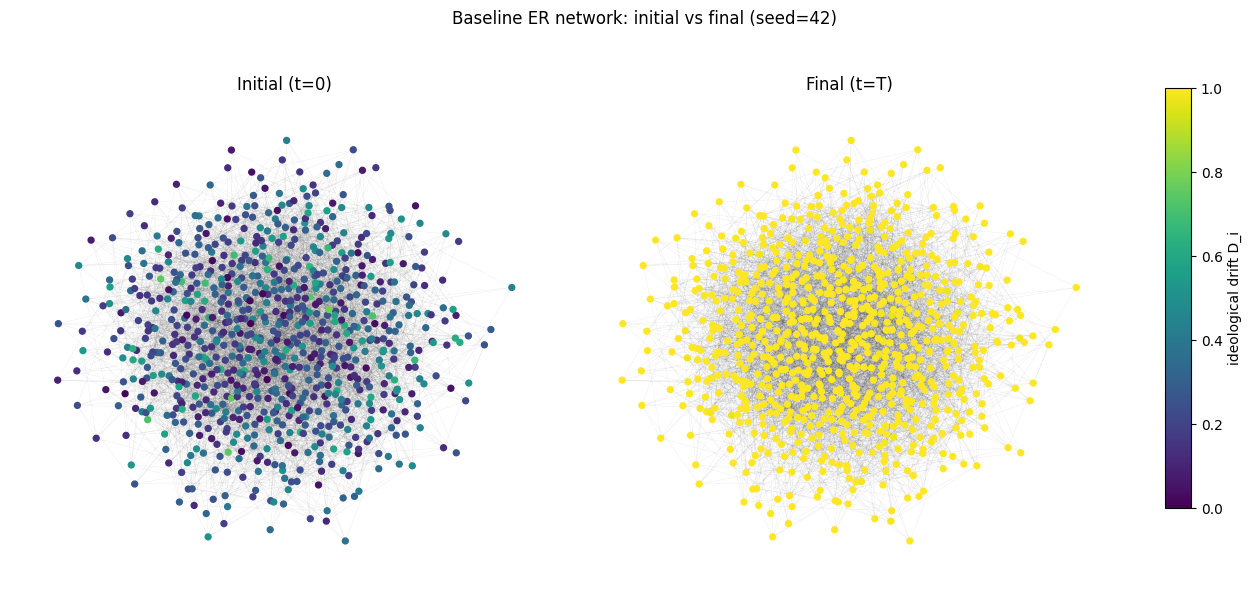

In [95]:
# Initial vs final network snapshot (main simulation; one baseline run)
# Compares the ER topology at t=0 to the final topology after edge decay and tie cutting.

snapshot_seed = RANDOM_SEED
snapshot_model = LonelinessModel(SCENARIOS["baseline"], seed=snapshot_seed)

# Capture initial state
G0 = snapshot_model.G.copy()
D0 = snapshot_model.D.copy()

# Run to completion
snapshot_metrics, _, Gf, state_f = snapshot_model.run(track=True)
Df = state_f["D"]

print("Initial edges:", G0.number_of_edges(), " | clustering:", nx.average_clustering(G0))
print("Final edges:", Gf.number_of_edges(), " | clustering:", nx.average_clustering(Gf))
print("Final snapshot metrics:", snapshot_metrics)

# Use one layout (from the initial graph) for both plots so topology changes are visually comparable.
pos = nx.spring_layout(G0, seed=1, iterations=50)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# Leave room on the right for a shared colorbar.
fig.subplots_adjust(right=0.88, wspace=0.08)

for ax, G, D, title in [
    (axes[0], G0, D0, "Initial (t=0)"),
    (axes[1], Gf, Df, "Final (t=T)"),
]:
    ax.axis("off")
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=D,
        cmap="viridis",
        vmin=0,
        vmax=1,
        node_size=18,
    )
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08, width=0.3)
    ax.set_title(title)

# Put the colorbar in its own axis so it does not overlap the right subplot.
cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(nodes, cax=cax)
cbar.set_label("ideological drift D_i")
fig.suptitle(f"Baseline ER network: initial vs final (seed={snapshot_seed})", y=0.98)
fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.95])
save_fig(fig, 'er_network_initial_vs_final2.png')
plt.show()


## Baseline Monte Carlo mean trajectories (for theory)

Tracking full time series for all 4 scenarios × 200 runs would be expensive.
Instead, I run a smaller baseline-only Monte Carlo batch with `track=True` to estimate expected trajectories and compare them to theory.
Results are cached on disk so reruns are faster.


In [90]:
# Baseline Monte Carlo time-series cache (used for theory-vs-expected comparison)
# This is separate from the main experiment cache and is used to plot empirical mean
# trajectories with uncertainty bands.
TS_RUNS = 30  # increase for tighter bands
# Use a seed offset so these runs do not overlap with the main Monte Carlo runs.
TS_SEED_OFFSET = 50000

ts_config = {
    'version': 1,
    'params': BASE_PARAMS,
    'runs': TS_RUNS,
    'seed': RANDOM_SEED,
    'seed_offset': TS_SEED_OFFSET,
}
os.makedirs('.cache', exist_ok=True)
ts_key = config_hash(ts_config)
ts_path = os.path.join('.cache', f'baseline_ts_{ts_key}.npz')

T = int(BASE_PARAMS['T'])

if os.path.exists(ts_path):
    data = np.load(ts_path)
    mean_I_runs = data['mean_I_runs']
    mean_R_runs = data['mean_R_runs']
    mean_D_runs = data['mean_D_runs']
    mean_R1S_runs = data['mean_R1S_runs']
    frac_bounds_runs = data['frac_bounds_runs']
    print('Loaded cached baseline time series from', ts_path)
else:
    mean_I_runs = np.zeros((TS_RUNS, T + 1))
    mean_R_runs = np.zeros((TS_RUNS, T + 1))
    mean_D_runs = np.zeros((TS_RUNS, T + 1))
    mean_R1S_runs = np.zeros((TS_RUNS, T))
    frac_bounds_runs = np.zeros((TS_RUNS, T))

    for r in range(TS_RUNS):
        m = LonelinessModel(BASE_PARAMS, seed=RANDOM_SEED + TS_SEED_OFFSET + r)
        I0, R0, D0 = float(np.mean(m.I)), float(np.mean(m.R)), float(np.mean(m.D))
        _, series_r, _, _ = m.run(track=True)
        mean_I_runs[r, :] = np.array([I0] + list(series_r['mean_I']))
        mean_R_runs[r, :] = np.array([R0] + list(series_r['mean_R']))
        mean_D_runs[r, :] = np.array([D0] + list(series_r['mean_D']))
        mean_R1S_runs[r, :] = np.array(series_r['mean_R_1minusS'])
        frac_bounds_runs[r, :] = np.array(series_r['frac_D_at_bounds'])

    np.savez(
        ts_path,
        mean_I_runs=mean_I_runs,
        mean_R_runs=mean_R_runs,
        mean_D_runs=mean_D_runs,
        mean_R1S_runs=mean_R1S_runs,
        frac_bounds_runs=frac_bounds_runs,
    )
    print('Saved baseline time series to', ts_path)

def _mean_and_band(arr):
    """Compute a mean trajectory and a 95% normal-approximation band over runs."""
    mean = arr.mean(axis=0)
    se = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi

baseline_ts = {
    't': np.arange(T + 1),
    'mean_I': _mean_and_band(mean_I_runs),
    'mean_R': _mean_and_band(mean_R_runs),
    'mean_D': _mean_and_band(mean_D_runs),
    'mean_R1S': _mean_and_band(mean_R1S_runs),
    'frac_bounds': _mean_and_band(frac_bounds_runs),
}


Loaded cached baseline time series from .cache/baseline_ts_e420833ef1fb.npz


## Theoretical analysis (ER mean-field checks)

Comparing analytic expectations against empirical simulation outputs.



ER network theory vs empirical (t=0)
  n=800, p≈0.0150
  Expected mean degree: 12.00 | Empirical mean degree: 12.05
  Expected #edges: 4800 | Empirical #edges: 4821
  Expected clustering≈p: 0.0150 | Empirical clustering: 0.0152
Saved figure: figures/theory_vs_empirical_trajectories.png


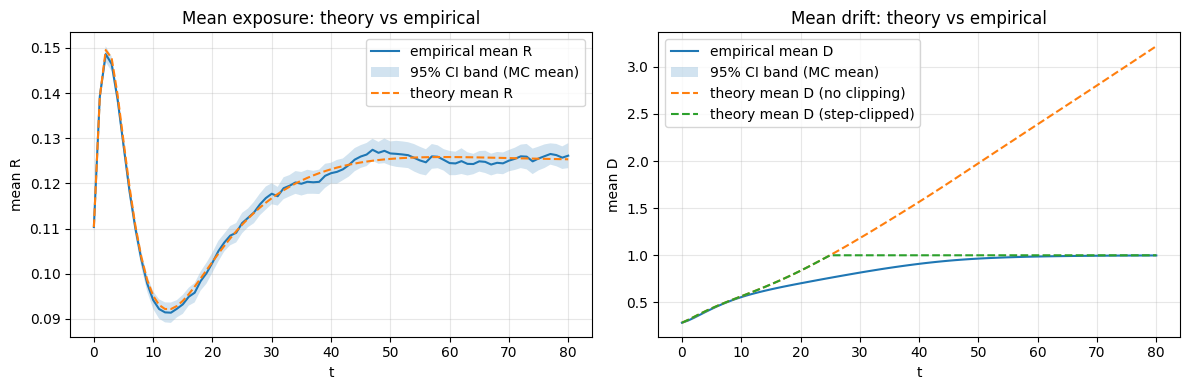

Saved figure: figures/theory_clipping_indicator.png


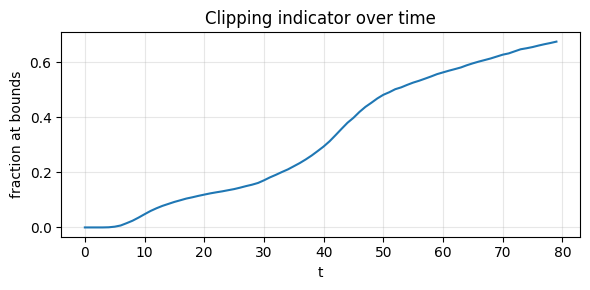

In [ ]:
# Theoretical vs empirical comparisons
n = BASE_PARAMS["n"]
mean_deg_target = float(BASE_PARAMS.get("er_mean_degree", 12))
p = mean_deg_target / (n - 1)

# Compare ER theory to the INITIAL network (before tie decay/cutting).
emp_avg_deg = float(np.mean([d for _, d in G_init.degree()]))
emp_edges = G_init.number_of_edges()
emp_clust = nx.average_clustering(G_init)

print("ER network theory vs empirical (t=0)")
print(f"  n={n}, p≈{p:.4f}")
print(f"  Expected mean degree: {(n-1)*p:.2f} | Empirical mean degree: {emp_avg_deg:.2f}")
print(f"  Expected #edges: {p*n*(n-1)/2:.0f} | Empirical #edges: {emp_edges}")
print(f"  Expected clustering≈p: {p:.4f} | Empirical clustering: {emp_clust:.4f}")

T = BASE_PARAMS["T"]

# Prefer Monte Carlo mean trajectories (baseline_ts); otherwise fall back to the single run above 
use_mc = "baseline_ts" in globals()

if use_mc:
    tgrid = baseline_ts["t"]
    mean_I = baseline_ts["mean_I"][0]
    mean_R_emp = baseline_ts["mean_R"][0]
    mean_R_lo, mean_R_hi = baseline_ts["mean_R"][1], baseline_ts["mean_R"][2]
    mean_D_emp = baseline_ts["mean_D"][0]
    mean_D_lo, mean_D_hi = baseline_ts["mean_D"][1], baseline_ts["mean_D"][2]
    mean_R_1minusS = baseline_ts["mean_R1S"][0]
    frac_bounds = baseline_ts["frac_bounds"][0]
else:
    tgrid = np.arange(T + 1)
    mean_I = np.array([float(np.mean(I0))] + list(series["mean_I"]))
    mean_R_emp = np.array([float(np.mean(R0))] + list(series["mean_R"]))
    mean_D_emp = np.array([float(np.mean(D0))] + list(series["mean_D"]))
    mean_R_lo = mean_R_emp
    mean_R_hi = mean_R_emp
    mean_D_lo = mean_D_emp
    mean_D_hi = mean_D_emp
    mean_R_1minusS = np.array(list(series["mean_R_1minusS"]))
    frac_bounds = np.array(list(series["frac_D_at_bounds"]))

# Predict mean R using conditional expectation given mean isolation (exact because p_alg is linear).
mean_R_pred = np.zeros(T + 1)
mean_R_pred[0] = mean_R_emp[0]
for t in range(T):
    p_alg_t = p0 + (pmax - p0) * mean_I[t]
    mean_R_pred[t+1] = (1.0 - alpha) * mean_R_pred[t] + alpha * p_alg_t

# Predict mean D using beta * mean(R*(1-S)). Compare both unclipped and step-clipped versions.
mean_D_pred = np.zeros(T + 1)
mean_D_pred_clip = np.zeros(T + 1)
mean_D_pred[0] = mean_D_emp[0]
mean_D_pred_clip[0] = mean_D_emp[0]
for t in range(T):
    mean_D_pred[t+1] = mean_D_pred[t] + beta * mean_R_1minusS[t]
    mean_D_pred_clip[t+1] = np.clip(mean_D_pred_clip[t] + beta * mean_R_1minusS[t], 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tgrid, mean_R_emp, label="empirical mean R")
if use_mc:
    axes[0].fill_between(tgrid, mean_R_lo, mean_R_hi, alpha=0.2, label="95% CI band (MC mean)")
axes[0].plot(tgrid, mean_R_pred, "--", label="theory mean R")
axes[0].set_title("Mean exposure: theory vs empirical")
axes[0].set_xlabel("t")
axes[0].set_ylabel("mean R")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tgrid, mean_D_emp, label="empirical mean D")
if use_mc:
    axes[1].fill_between(tgrid, mean_D_lo, mean_D_hi, alpha=0.2, label="95% CI band (MC mean)")
axes[1].plot(tgrid, mean_D_pred, "--", label="theory mean D (no clipping)")
axes[1].plot(tgrid, mean_D_pred_clip, "--", label="theory mean D (step-clipped)")
axes[1].set_title("Mean drift: theory vs empirical")
axes[1].set_xlabel("t")
axes[1].set_ylabel("mean D")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'theory_vs_empirical_trajectories.png')
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(frac_bounds, label="fraction of agents at D=0 or D=1")
plt.title("Clipping indicator over time")
plt.xlabel("t")
plt.ylabel("fraction at bounds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig2 = plt.gcf()
save_fig(fig2, 'theory_clipping_indicator.png')
plt.show()


## Theory vs Monte Carlo (final metrics; no rerun)

The time-series comparison above uses a single run as a trajectory-level sanity check.
For an **expected-value** comparison without rerunning Monte Carlo time series, we use the cached Monte Carlo outputs (final-run summaries).

**Exposure steady-state check:** if $\bar I$ is approximately stable late in the run, the exposure recursion
$R(t+1)=(1-\alpha)R(t)+\alpha E(t)$ implies a steady-state $\mathbb{E}[\bar R] \approx p_{alg}(\bar I)$.

**Drift rough check (mean-field):** using $S \approx \overline{w}\,(1-\bar I)$ and $\bar D(T) \approx \text{clip}(\bar D(0) + T\,\beta\,p_{alg}(\bar I)\,(1-S))$. This is only a coarse benchmark because it ignores time variation and nonlinear clipping.


Saved figure: figures/theory_vs_mc_final_metrics.png


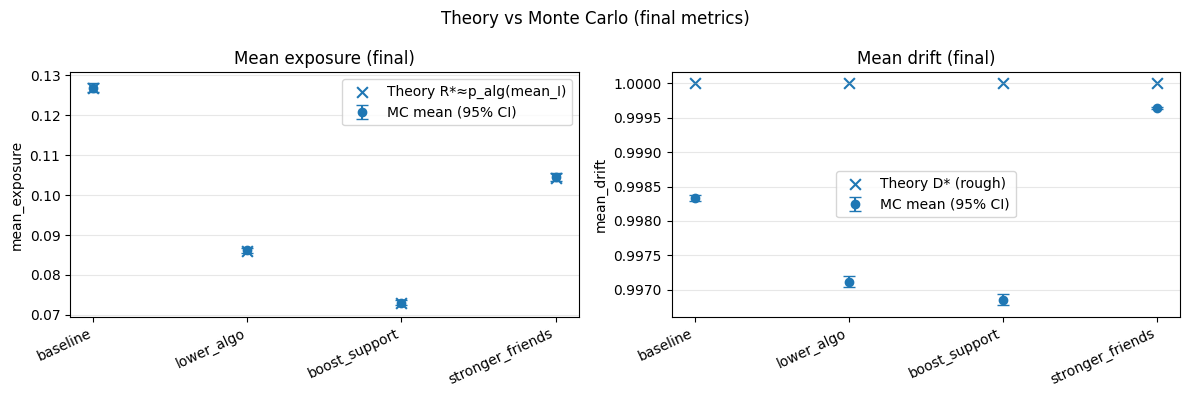

In [92]:
# Compare simple theoretical benchmarks to Monte Carlo final metrics (uses cached results)
# These are intentionally simple checks rather than a fully derived closed-form model.
def p_alg_from_I(mean_I, params):
    """Compute the linear algorithmic recommendation probability at mean isolation."""
    return float(params["p0"] + (params["p_max"] - params["p0"]) * mean_I)

def clip01(x):
    """Clip a scalar to [0, 1] to match the simulation's state clipping."""
    return max(0.0, min(1.0, float(x)))

def mc_mean_ci(metric, rows):
    """Compute the Monte Carlo mean and 95% CI for one metric across rows."""
    vals = [r[metric] for r in rows]
    return mean_ci(vals)

# Theoretical mean of initial drift from Beta(init_D_a, init_D_b).
D0_theory = float(BASE_PARAMS["init_D_a"]) / (float(BASE_PARAMS["init_D_a"]) + float(BASE_PARAMS["init_D_b"]))
T = int(BASE_PARAMS["T"])
beta = float(BASE_PARAMS["beta"])

scenarios = list(results.keys())
x = np.arange(len(scenarios))

mc_I = []
mc_I_ci = []
mc_R = []
mc_R_ci = []
mc_D = []
mc_D_ci = []
mc_w = []
mc_w_ci = []
theory_R = []
theory_D = []

for name in scenarios:
    rows = results[name]
    mI, (mI_lo, mI_hi) = mc_mean_ci("mean_isolation", rows)
    mR, (mR_lo, mR_hi) = mc_mean_ci("mean_exposure", rows)
    mD, (mD_lo, mD_hi) = mc_mean_ci("mean_drift", rows)
    mw, (mw_lo, mw_hi) = mc_mean_ci("avg_weight", rows)

    R_star = p_alg_from_I(mI, SCENARIOS[name])
    S_hat = float(mw * (1.0 - mI))
    D_star = clip01(D0_theory + T * beta * R_star * (1.0 - S_hat))

    mc_I.append(mI); mc_I_ci.append((mI_lo, mI_hi))
    mc_R.append(mR); mc_R_ci.append((mR_lo, mR_hi))
    mc_D.append(mD); mc_D_ci.append((mD_lo, mD_hi))
    mc_w.append(mw); mc_w_ci.append((mw_lo, mw_hi))
    theory_R.append(R_star)
    theory_D.append(D_star)

mc_R = np.array(mc_R); theory_R = np.array(theory_R)
mc_D = np.array(mc_D); theory_D = np.array(theory_D)

def yerr_from_ci(means, cis):
    """Convert (lo, hi) confidence intervals into Matplotlib errorbar yerr format."""
    lo = np.array([c[0] for c in cis])
    hi = np.array([c[1] for c in cis])
    return np.vstack([means - lo, hi - means])

R_yerr = yerr_from_ci(mc_R, mc_R_ci)
D_yerr = yerr_from_ci(mc_D, mc_D_ci)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(x, mc_R, yerr=R_yerr, fmt="o", capsize=4, label="MC mean (95% CI)")
axes[0].scatter(x, theory_R, marker="x", s=60, label="Theory R*≈p_alg(mean_I)")
axes[0].set_title("Mean exposure (final)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios, rotation=25, ha="right")
axes[0].set_ylabel("mean_exposure")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].errorbar(x, mc_D, yerr=D_yerr, fmt="o", capsize=4, label="MC mean (95% CI)")
axes[1].scatter(x, theory_D, marker="x", s=60, label="Theory D* (rough)")
axes[1].set_title("Mean drift (final)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios, rotation=25, ha="right")
axes[1].set_ylabel("mean_drift")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

fig.suptitle("Theory vs Monte Carlo (final metrics)")
plt.tight_layout()
save_fig(fig, 'theory_vs_mc_final_metrics.png')
plt.show()


## Extension: SBM “high school” network

As an extension, we replace the ER graph with a **stochastic block model (SBM)** to represent grade-/group-based clustering typical of a high school.
We keep the *same* simulation class (`LonelinessModel`) and only change network parameters.


SBM results cache: .cache/sbm_results_f749ce0b9935.json
Saved figure: figures/sbm_mc_histograms_mean_drift_isolation.png


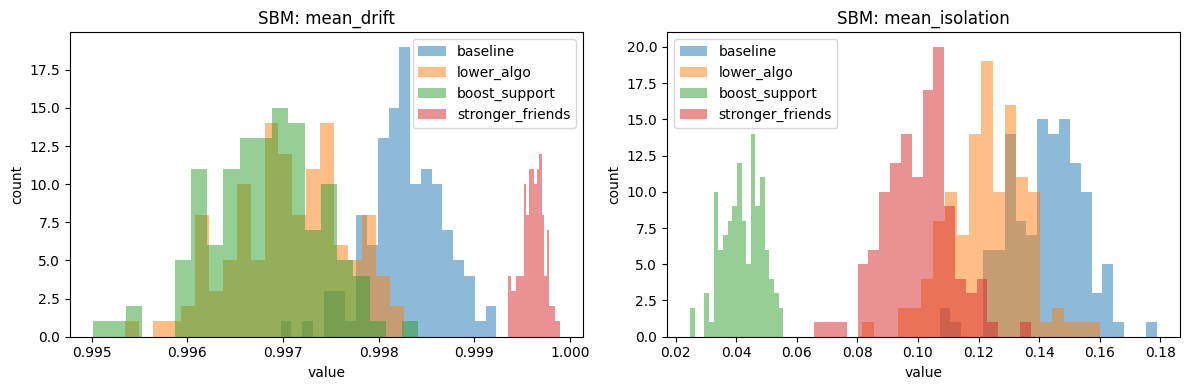

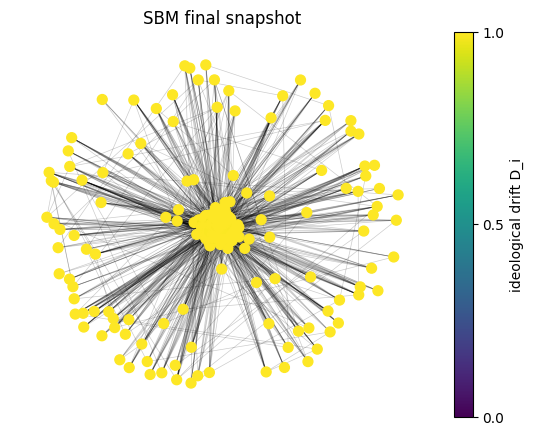

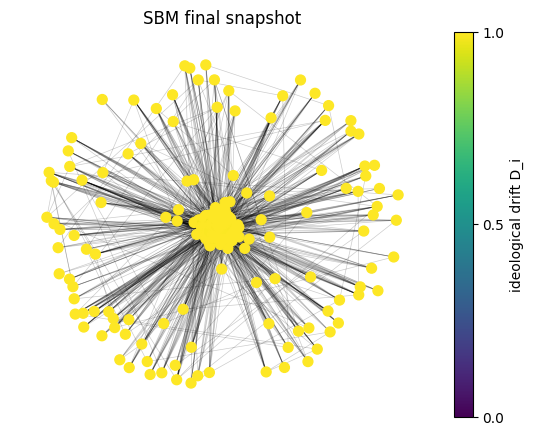

In [ ]:
# SBM extension: intervention comparison on a clustered (high-school-like) topology
SBM_BASE = dict(BASE_PARAMS)
SBM_BASE.update({
    'network': 'sbm',
    'sbm_block_sizes': [200, 200, 200, 200],
    'sbm_p_in': 0.04,
    'sbm_p_out': 0.004,
})

SBM_SCENARIOS = {
    'baseline': dict(SBM_BASE),
    'lower_algo': {**SBM_BASE, 'p_max': 0.35},
    'boost_support': {**SBM_BASE, 'delta': 0.40},
    'stronger_friends': {**SBM_BASE, 'beta_friend': 0.85},
}

SBM_RUNS = 120

# Cache configuration for SBM runs.

sbm_cache_config = {
    'version': 1,
    'scenarios': SBM_SCENARIOS,
    'num_runs': SBM_RUNS,
    'seed': RANDOM_SEED,
}

def _compute_sbm_results():
    """Compute Monte Carlo results for the SBM topology extension."""
    return ExperimentRunner(SBM_SCENARIOS, SBM_RUNS, seed=RANDOM_SEED).run()

sbm_results, sbm_cache_path = load_or_compute_json('sbm_results', sbm_cache_config, _compute_sbm_results)
print('SBM results cache:', sbm_cache_path)

metrics_to_plot = ['mean_drift', 'mean_isolation']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    for name, rows in sbm_results.items():
        values = [r[metric] for r in rows]
        ax.hist(values, bins=20, alpha=0.5, label=name)
    ax.set_title(f'SBM: {metric}')
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend()

plt.tight_layout()
save_fig(fig, 'sbm_mc_histograms_mean_drift_isolation.png')
plt.show()

# Final snapshot (one SBM run)
sbm_model = LonelinessModel(SBM_BASE, seed=RANDOM_SEED)
_, _, Gf, st = sbm_model.run(track=True)
LonelinessModel.plot_network(Gf, st['D'], 'SBM final snapshot', save_path=os.path.join(FIG_DIR, 'sbm_final_snapshot.png'))
